In [ ]:
# Assignment  : 7th july
Question Answer:-

Question 1: Explain the difference between:
● "r", "w", "a", "rb"
Ans->  "r"(Read) : opens a file for reading text.The file must already exist,or it gives an error.
       "w"(write): opens a file fo writing text.It completely deletes existing content or creates a new file.
       "a"(Append): opens a file to add text at the very end.It preserves existing content.
       "rb"(Read binary): opens a file for reading non-text data like images ,audio,or PDFs in bytes.
  
● Why context managers (with open()) are preferred.
Ans-> In python a context manager is a tool that allocates and release resourses  precisely when you want it to.
               when you deal with files,your computer allocates limited system resourses(like file handles and 
               memory) to look inside that file. A context manager ensures these resourses are cleanly cleaned 
               up the exact moment you are done.  
      1. Gauranteed Automatic closing:
         The problem: In the traditional way (file = open()),you must remember to explicitly type file.close() 
         at the end.If you forgoot,the file stays open in your computer's backround.over time pile up,drain 
         server memory,and can slow down or crash your system.
         
         The solution : With with open(),you don't need to write file.close().Python tracks,the indentation
         block.The exact microsecond the code move outside that indented block ,Python automatically shuts the
         file.
      2.Error handling : It gaurantees the file closes safely even if your code crashes or hits an error halfway
      through.
      3. Cleaner code : you do not need to manually write file.close(), which keeps the code shorter and cleaner.
         
● What happens if a file is not properly closed in a production system.
Ans-> The following things happen if a file is not properly closed in a producion system:
         1.Resource leaks : The operating system keep a connection open to the file,wasting system memory.
         2.Data loss : system buffers might not flush completely,causing written data to disappear or corrupt.
         3.File locking : other applications or processes might get blocked from reading or editing the file.
         4.system crashes : If two many files stay open,the serverwill hit its limit and crashes completely.


Question 2: You are given a CSV file sales.csv containing:
product,price,quantity
Laptop,50000,5
Phone,20000,10
Tablet,15000,7
Tasks:
1. Read the file using Python.
2. Compute total revenue per product.
3. Write result to a new file revenue.csv.
4. Explain limitations of manual CSV handling vs Pandas. 

In [7]:
import csv

# Given input ko sales.csv file me likhna
with open('sales.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['product', 'price', 'quantity'])
    writer.writerow(['Laptop', 50000, 5])
    writer.writerow(['Phone', 20000, 10])
    writer.writerow(['Tablet', 15000, 7])

# sales.csv ko read karna aur result revenue.csv me write karna
with open('sales.csv', 'r') as infile, open('revenue.csv', 'w', newline='') as outfile:

    reader = csv.DictReader(infile)

    # revenue.csv ke columns
    fieldnames = ['product', 'revenue']
    writer = csv.DictWriter(outfile, fieldnames=fieldnames)

    writer.writeheader()

    for row in reader:
        product = row['product']
        price = int(row['price'])
        quantity = int(row['quantity'])

        revenue = price * quantity

        # Screen par print karna
        print(product, 'Revenue =', revenue)

        # revenue.csv me write karna
        writer.writerow({
            'product': product,
            'revenue': revenue
        })

print('Result written to revenue.csv')

Laptop Revenue = 250000
Phone Revenue = 200000
Tablet Revenue = 105000
Result written to revenue.csv


4. Explain limitations of manual CSV handling vs Pandas.
 Ans->Limitations of Manual CSV Handling Compared to Pandas
      1. More Coding Effort
         In manual CSV handling, we need to write loops, convert data types, and calculate values ourselves. This makes the             program longer and more difficult to maintain.

         Pandas advantage: Pandas performs these tasks with very few lines of code.
      2. Slower for Large Files
         The csv module reads data row by row, so processing large datasets takes more time.

         Pandas advantage: Pandas is optimized for handling large datasets efficiently and works much faster.

      3. Manual Data Type Conversion
        Values read from a CSV file are treated as strings, so we must manually convert them using int() or float().

         advantage: Pandas automatically detects and assigns appropriate data types in many cases."
      4. Difficult Handling of Missing Values

         With manual CSV handling, we need to check each value and write extra conditions for missing data.

         Pandas advantage: Missing values are handled using built-in features such as isna(), fillna(), and dropna().

      5. Complex Data Analysis

         Operations such as filtering, sorting, grouping, and finding totals require custom logic and loops.

         Pandas advantage: Pandas provides simple built-in methods like groupby(), sort_values(), and conditional filtering.

Question 3: You receive JSON data from an API:
{
"customers": [
{"id": 1, "name": "Amit", "purchase": 5000},
{"id": 2, "name": "Sara", "purchase": 7000}
]
}
Tasks:
1. Load the JSON.
2. Extract all customer names.
3. Compute total purchase value.
4. Explain why JSON is widely used in ML pipelines.

In [9]:
import json

# Your given JSON data
json_data = '''
{
  "customers": [
    {"id": 1, "name": "Amit", "purchase": 5000},
    {"id": 2, "name": "Sara", "purchase": 7000}
  ]
}
'''

# 1. Load the JSON
data = json.loads(json_data)

# 2. Extract all customer names
customer_names = [customer["name"] for customer in data["customers"]]

# 3. Compute total purchase value
total_purchase = sum(customer["purchase"] for customer in data["customers"])

# Display results
print("Loaded JSON Data:")
print(data)

print("\nCustomer Names:")
print(customer_names)

print("\nTotal Purchase Value:")
print(total_purchase)

Loaded JSON Data:
{'customers': [{'id': 1, 'name': 'Amit', 'purchase': 5000}, {'id': 2, 'name': 'Sara', 'purchase': 7000}]}

Customer Names:
['Amit', 'Sara']

Total Purchase Value:
12000


TASK :4. Explain why JSON is widely used in ML pipeline.
      ANSWER -> 1.Easy to read and understand
                  JSON uses a simple key-value structure, so humans can easily inspect configurations and data.
                Language-independent
                2.JSON can be processed by Python, Java, JavaScript, C++, and many other languages. This is useful when                          different components of an ML pipeline use different technologies.
                3.Good for configuration
                 ML experiments involve many parameters—learning rate, model type, batch size, dataset paths, etc. JSON                         provides a convenient way to store and pass these settings.
                4.Works well with APIs
                  ML systems often communicate through REST APIs. JSON is a common format for sending inputs, predictions,                       metadata, and results between services.
                  Supports structured data
                5.JSON can represent nested objects and arrays, making it useful for storing things such as model metadata,                      feature information, experiment results, and pipeline settings.
                6.Easy to serialize and deserialize
                  Programs can quickly convert objects into JSON (serialization) and JSON back into objects (deserialization).
                7.Widely supported by tools
                  Cloud platforms, databases, ML frameworks, workflow tools, and monitoring systems commonly provide JSON                        support, making integration easier.

Question 4:Create NumPy arrays for: 
● Product prices 
● Quantities 
Then: 
1. Compute revenue using vectorized operations. 
2. Compare performance of Python loop vs NumPy. 
3. Explain broadcasting with example.

In [1]:
import numpy as np
import time

# Create NumPy arrays
prices = np.array([100, 250, 50, 120, 300])
quantities = np.array([2, 3, 5, 4, 1])

# 1. Compute revenue 
revenue = prices * quantities

print("Prices:", prices)
print("Quantities:", quantities)
print("Revenue:", revenue)
print("Total Revenue:", np.sum(revenue))

Prices: [100 250  50 120 300]
Quantities: [2 3 5 4 1]
Revenue: [200 750 250 480 300]
Total Revenue: 1980


TASK 2 ANSWER: Python Loop:
               In a Python loop, each element of the array is processed one by one. For example, to calculate revenue, Python                 takes one price and one quantity, multiplies them, and then moves to the next pair. This involves repeated                     Python-level operations, which makes it slower when working with large amounts of data.

               NumPy:
               NumPy uses vectorized operations, meaning it can perform the same operation on an entire array at once. Instead                of processing each element through a Python loop, NumPy uses optimized, low-level implementations to perform                   calculations efficiently.

               Performance Comparison:

               1.Python loops are generally slower for large datasets.
               2.NumPy vectorized operations are generally faster.
               3.NumPy requires less code for array calculations.
               4.NumPy operations are implemented using optimized low-level code, reducing the overhead of Python loops.

TASK 3 ANSWER: Broadcasting in NumPy

               Broadcasting is a feature in NumPy that allows arithmetic operations between arrays of different shapes. NumPy                 automatically adjusts the smaller array or value so that the operation can be performed.

               In simple words, broadcasting means applying one value or a smaller array to every element of a larger array.

In [2]:
#example for task 3:-
import numpy as np

A = np.array([[1, 2, 3],
              [4, 5, 6]])

B = np.array([10, 20, 30])

print(A + B)

[[11 22 33]
 [14 25 36]]


Question 5:  Using sales data: 
1. Plot line chart for monthly revenue. 
2. Plot bar chart for product comparison. 
3. Add labels, title, legend. 
4. Explain why visualization is essential before modeling.

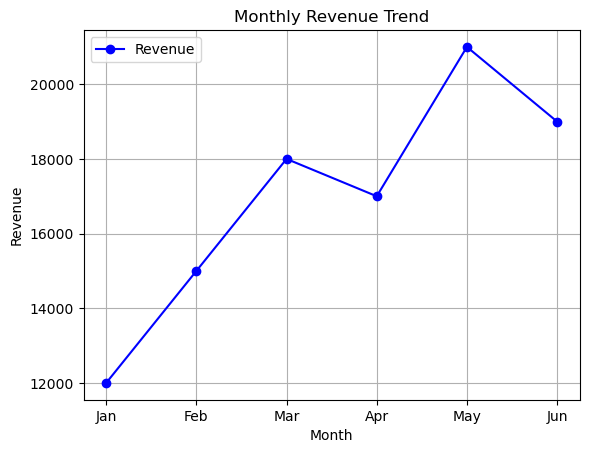

In [6]:
# Question 1: Line chart for monthly revenue
import matplotlib.pyplot as plt

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
revenue = [12000, 15000, 18000, 17000, 21000, 19000]

plt.plot(months, revenue, marker='o', color='blue', label='Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Monthly Revenue Trend')
plt.legend()
plt.grid(True)
plt.show()

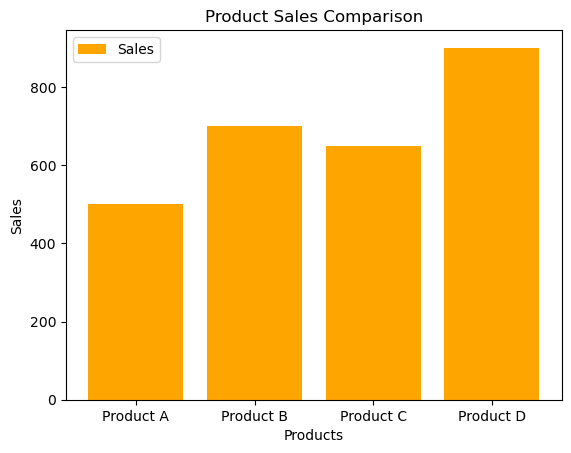

In [9]:
# Question 2: Bar chart for product comparison
import matplotlib.pyplot as plt

products = ['Product A', 'Product B', 'Product C', 'Product D']
sales = [500, 700, 650, 900]

plt.bar(products, sales, color='orange', label='Sales')
plt.xlabel('Products')
plt.ylabel('Sales')
plt.title('Product Sales Comparison')
plt.legend()

plt.show()

TASK 4 ANSWER:-
Visualization is essential before modeling because it helps understand the data clearly before applying any machine learning or statistical model.

    A.Identifies trends and patterns: reveals increasing, decreasing, seasonal, or cyclical behavior in the data.

    B.Detects outliers: unusual values become visible and can be investigated or removed.

    C.Finds missing or inconsistent data: gaps and irregularities are easier to spot visually.

    D.Shows relationships between variables: helps determine whether variables are positively related, negatively related, or        unrelated.

    E.Checks data distribution: indicates whether data are skewed, normal, or spread unevenly, which affects model choice.

    F.Supports feature selection: highlights which variables appear important for prediction.

    G.Improves model selection: understanding data behavior helps choose appropriate algorithms and preprocessing methods.

Question 6: Load a CSV into Pandas and: 
1. Display first 5 rows. 
2. Check missing values. 
3. Compute summary statistics. 
4. Select rows where sales > 15000.

In [ ]:
# ANSWER FOR QUESTION 6:
import pandas as pd

# Load CSV file
df = pd.read_csv('sales_data.csv')

# 1. Display first 5 rows
print('First 5 rows:')
print(df.head())

# 2. Check missing values
print('\nMissing values:')
print(df.isnull().sum())

# 3. Compute summary statistics
print('\nSummary statistics:')
print(df.describe())

# 4. Select rows where sales > 15000
print('\nRows where sales > 15000:')
print(df[df['sales'] > 15000])

Question 7: Dataset contains: 
● Missing values 
● Duplicate rows 
● Inconsistent capitalization 
Tasks: 
1. Remove duplicates. 
2. Handle missing values. 
3. Standardize text columns. 
4. Explain impact of dirty data on ML performance.

In [1]:
# ANSWER FOR QUESTION 7:-
import pandas as pd

# Example dataset
data = {
    'Name': ['Alice', 'bob', 'ALICE', 'Charlie', None],
    'City': ['Delhi', 'mumbai', 'DELHI', None, 'Kolkata'],
    'Salary': [50000, 60000, 50000, None, 55000]
}

df = pd.DataFrame(data)

# Add a duplicate row for demonstration
df = pd.concat([df, df.iloc[[0]]], ignore_index=True)

# 1. Remove duplicate rows
df = df.drop_duplicates()

# 2. Handle missing values
df['Name'] = df['Name'].fillna('Unknown')
df['City'] = df['City'].fillna('Unknown')
df['Salary'] = df['Salary'].fillna(df['Salary'].mean())
# 3. Standardize text columns
df['Name'] = df['Name'].str.lower().str.strip()
df['City'] = df['City'].str.lower().str.strip()

print(df)

# 4. Impact of dirty data on ML performance
print('\nImpact of dirty data on ML performance:')
print('- Missing values can cause errors or biased predictions.')
print('- Duplicate rows can overemphasize certain patterns.')
print('- Inconsistent capitalization creates multiple categories for the same value.')
print('- Dirty data reduces model accuracy and reliability.')

      Name     City   Salary
0    alice    delhi  50000.0
1      bob   mumbai  60000.0
2    alice    delhi  50000.0
3  charlie  unknown  53750.0
4  unknown  kolkata  55000.0

Impact of dirty data on ML performance:
- Missing values can cause errors or biased predictions.
- Duplicate rows can overemphasize certain patterns.
- Inconsistent capitalization creates multiple categories for the same value.
- Dirty data reduces model accuracy and reliability.


Question 8:Using Plotly: 
1. Create interactive bar chart of sales. 
2. Create pie chart for category distribution. 
3. Add hover information. 
4. Explain difference between: 
   ○ Static visualization (Matplotlib/Seaborn) 
   ○ Interactive dashboards (Plotly) 
Discuss where interactive dashboards are critical in business environments.

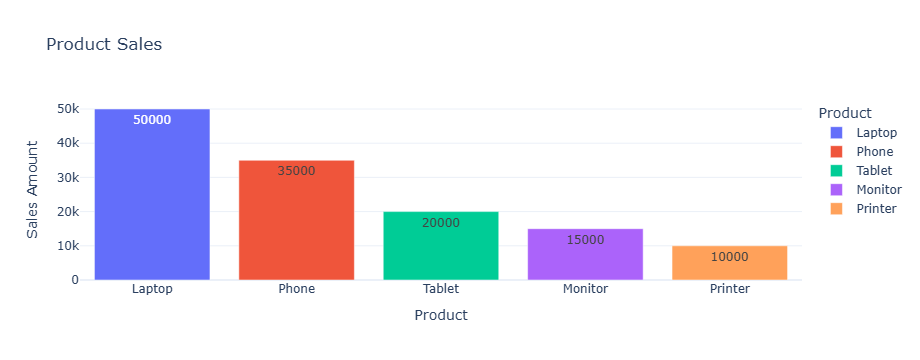

In [13]:
# TASK 1 ANSWER WITH HOVER INFORMATION:-
import plotly.express as px

# Sample sales data
df_sales = pd.DataFrame({
    'Product': ['Laptop', 'Phone', 'Tablet', 'Monitor', 'Printer'],
    'Sales': [50000, 35000, 20000, 15000, 10000]
})

# Interactive bar chart
fig = px.bar(
    df_sales,
    x='Product',
    y='Sales',
    title='Product Sales',
    color='Product',
    text='Sales',
    hover_data={'Sales': ':,.0f'}
)
fig.update_layout(
    xaxis_title='Product',
    yaxis_title='Sales Amount',
    template='plotly_white'
)



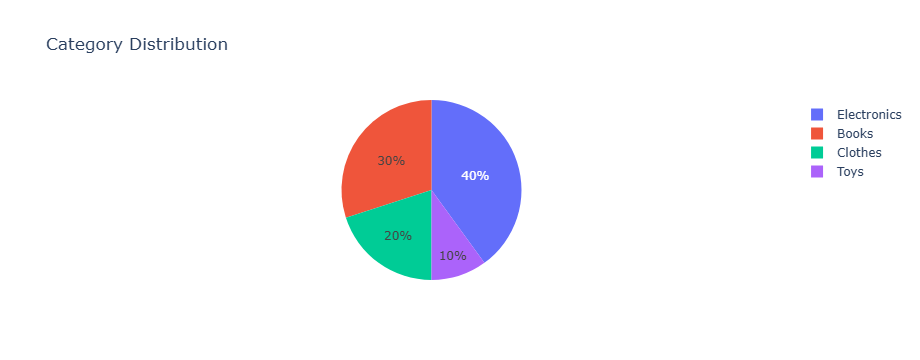

In [14]:
# TASK 2 ANSWER WITH HOVER INFORMATION :-
import plotly.graph_objects as go

# Simple category data
categories = ['Books', 'Electronics', 'Clothes', 'Toys']
values = [30, 40, 20, 10]

fig = go.Figure(
    data=[
        go.Pie(
            labels=categories,
            values=values,
            hovertemplate='Category: %{label}<br>Value: %{value}<br>Percentage: %{percent}<extra></extra>'
        )
    ]
)

fig.update_layout(title='Category Distribution')

fig.show()

#TASK 4 ANSWER:-
Difference Between Static Visualization and Interactive Dashboard
1. Nature of the Chart:

      Static Visualization (Matplotlib/Seaborn): The chart is fixed after creation. It looks the same every time it is viewed.

      interactive Dashboard (Plotly): The chart is dynamic and can change based on user interaction such as hover, zoom, or filter.

2. User Interaction:

   Static Visualization: Users can only look at the graph; they cannot interact with it.

   Interactive Dashboard: Users can hover over points, click legends, zoom in/out, and explore the data.

3. Display of Information:

   Static Visualization: All information must be shown directly on the chart, which may make it crowded.

   Interactive Dashboard: Extra information can appear in tooltips when the user hovers over the chart, keeping it clean.

4. Data Exploration:

   Static Visualization: Exploring details is difficult because the chart is fixed.

   Interactive Dashboard: Users can easily explore trends, compare values, and inspect details interactively.

5. Output Format:

   Static Visualization: Usually saved as PNG, JPG, PDF, or printed in reports.

   Interactive Dashboard: Usually displayed in a web browser, HTML page, or dashboard application.


@ -> Where Interactive Dashboards Are Critical in Business

    1.Interactive dashboards are critical when decisions must be taken quickly.

    2.Retail: monitor daily sales and inventory.

    3.Finance: track revenue, expenses, and fraud alerts in real time.

    4.Manufacturing: monitor production and machine status continuously.

    5.Healthcare: track patients, beds, and emergency resources.

    6.Logistics: monitor deliveries and shipment delays.


Question 9: 
Write a Python program to: 
1. Create a text file called data.txt 
2. Write 5 lines of product information 
3. Read the file and print only lines containing the word "Laptop" 
4. Use a context manager 
Explain why context managers prevent memory leaks. 

In [ ]:
# 1. Create and write to data.txt using a context manager
with open('data.txt', 'w') as file:
    file.write('Laptop Dell 55000\n')
    file.write('Phone Samsung 25000\n')
    file.write('Laptop HP 60000\n')
    file.write('Tablet Lenovo 18000\n')
    file.write('Laptop Acer 45000\n')

# 2. Read the file and print lines containing 'Laptop'
print('Lines containing Laptop:')

with open('data.txt', 'r') as file:
    for line in file:
        if 'Laptop' in line:
            print(line.strip())

# TASK 4 ANSWER:-
    Why Context Managers Prevent Memory Leaks (Theory)

      A context manager is a Python mechanism that automatically manages resources such as files, database connections,              sockets, and network streams. It is commonly used with the with statement.

     When a resource is opened, the operating system allocates memory and other system resources for it. If the resource is         not released properly, those resources remain occupied even after the program no longer needs them. This situation is          called a resource leak, and over time it can lead to increased memory usage and reduced system performance.

     A context manager prevents this problem by guaranteeing that cleanup code is executed automatically when the block of          code finishes. In Python, the context manager internally uses methods such as __enter__() (when entering the block) and        __exit__() (when leaving the block). The __exit__() method is executed whether the block ends normally or because of an        exception.

Question 10: You are hired as a Data Analyst at an online learning company. 
The company offers multiple courses and wants to understand: 
● Revenue trends 
● Student performance 
● Course popularity 
● Engagement patterns 
You must design a simple analytics solution using Python and Data Science tools. 
Design a CSV file structure that stores:
● Course Name 
● Student ID 
● Course Fee 
● Completion Percentage 
● Rating (1–5) 
Write a Python program to: 
1. Create this CSV file. 
2. Add at least 10 sample records. 
3. Read the file and calculate total revenue. 
Explain why using with open() is better than manually opening and closing files.

In [15]:
import csv

# Define the dataset with 10 sample records
data = [
    ["Python for Beginners", "STU001", 49.99, 100, 5],
    ["Data Science Basics", "STU002", 99.99, 85, 4],
    ["Machine Learning 101", "STU003", 149.99, 45, 4],
    ["Python for Beginners", "STU004", 49.99, 10, 3],
    ["Web Development Boot camp", "STU005", 79.99, 90, 5],
    ["Data Science Basics", "STU006", 99.99, 100, 5],
    ["AI & Ethics", "STU007", 29.99, 60, 2],
    ["Machine Learning 101", "STU008", 149.99, 12, 1],
    ["Web Development Boot camp", "STU009", 79.99, 100, 4],
    ["Python for Beginners", "STU010", 49.99, 75, 4]

]
headers = ["Course Name", "Student ID", "Course Fee", "Completion Percentage", "Rating"]
file_name = "course_analytics.csv"

# 1 & 2. Create the CSV file and write the records
with open(file_name, mode="w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow(headers)  # Write header row
    writer.writerows(data)    # Write sample records

print(f"'{file_name}' created successfully with 10 records.\n")

# 3. Read the file and calculate total revenue
total_revenue = 0.0

with open(file_name, mode="r", encoding="utf-8") as file:
    reader = csv.reader(file)
    next(reader)  # Skip the header row

    for row in reader:
        # Course Fee is in the 3rd column (index 2)
        total_revenue += float(row[2])

print(f"Total Revenue: ${total_revenue:.2f}")

'course_analytics.csv' created successfully with 10 records.

Total Revenue: $839.90


#Explain why using with open() is better than manually opening and closing files.
 Why with open() is Better Than Manual File Handling
    Using the with statement (also known as a Context Manager) is the recommended best practice in Python for several critical     reasons:
    1.Automatic Resource Management: It guarantees that the file is automatically closed as soon as the code block finishes          executing, even if an error or exception occurs inside the block.
    3.Prevents Memory Leaks: If you open a file manually using file = open() and forget to call file.close(), the file               descriptor remains open in system memory. Over time, leaving files open can drain system resources or lock the file from        being edited by other programs.
    4.Cleaner and Cleaner Code: It eliminates the need to explicitly write repetitive try...finally blocks just to ensure            file.close() runs under unexpected crashes. It keeps your analytics scripts readable and concise